# Perceptrón multicapa (MLP) para regresión

En este notebook veremos cómo funciona un **MLP** en un problema de regresión.

Un MLP:
- recibe datos de entrada
- los transforma capa a capa
- aprende relaciones no lineales complejas

A diferencia de modelos como la regresión lineal, aquí el modelo puede aprender funciones mucho más flexibles.

In [11]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

## 1. Generación de datos

Usamos una relación no lineal para ver mejor la capacidad del MLP.

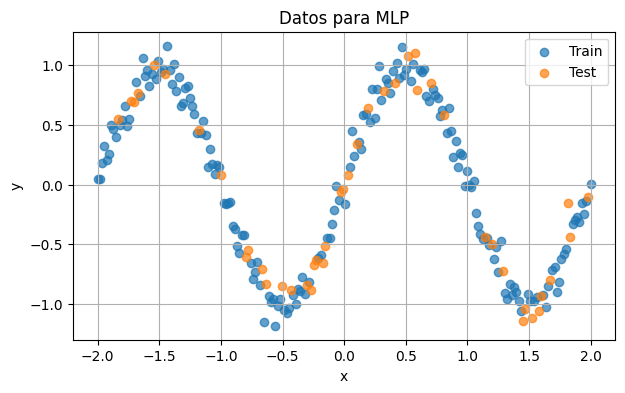

In [12]:
np.random.seed(42)

X = np.linspace(-2, 2, 220).reshape(-1, 1)
y = np.sin(np.pi * X[:, 0]) + 0.1 * np.random.randn(220)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

plt.figure(figsize=(7,4))
plt.scatter(X_train, y_train, alpha=0.7, label='Train')
plt.scatter(X_test, y_test, alpha=0.7, label='Test')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Datos para MLP')
plt.legend()
plt.grid(True)
plt.show()

## 2. Escalado de datos

En redes neuronales es habitual escalar las variables de entrada.

Esto ayuda a que el entrenamiento sea más estable.

In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 3. Entrenamiento del modelo

Este modelo se entrena de forma iterativa usando optimización basada en gradiente.

In [14]:
mlp = MLPRegressor(
    hidden_layer_sizes=(64, 64),
    activation='tanh',
    solver='adam',
    max_iter=1000,
    random_state=42
)

mlp.fit(X_train_scaled, y_train)

y_pred = mlp.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)

print(f"MSE: {mse:.4f}")
print(f"Número de iteraciones: {mlp.n_iter_}")

MSE: 0.0213
Número de iteraciones: 453


## 4. Visualización de la predicción

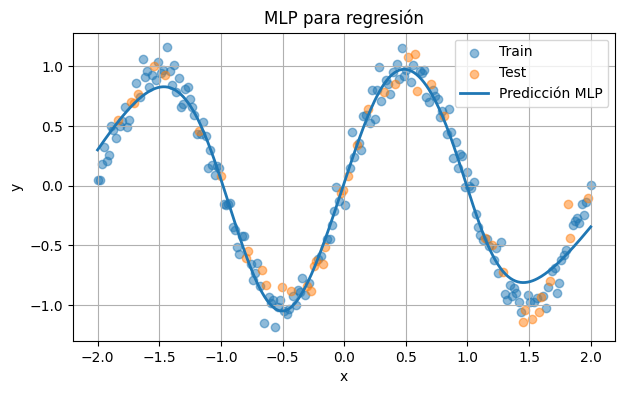

In [15]:
X_plot = np.linspace(X.min(), X.max(), 400).reshape(-1, 1)
X_plot_scaled = scaler.transform(X_plot)
y_plot = mlp.predict(X_plot_scaled)

plt.figure(figsize=(7,4))
plt.scatter(X_train, y_train, alpha=0.5, label='Train')
plt.scatter(X_test, y_test, alpha=0.5, label='Test')
plt.plot(X_plot, y_plot, linewidth=2, label='Predicción MLP')
plt.xlabel('x')
plt.ylabel('y')
plt.title('MLP para regresión')
plt.legend()
plt.grid(True)
plt.show()

## 5. Curva de pérdida

La red va ajustando sus pesos para ir reduciendo la función de pérdida.

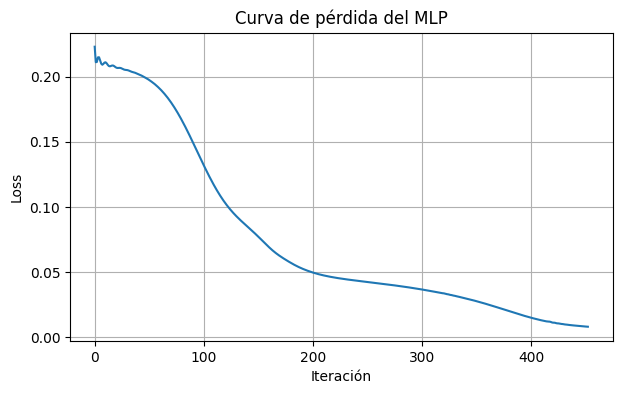

In [16]:
plt.figure(figsize=(7,4))
plt.plot(mlp.loss_curve_)
plt.xlabel('Iteración')
plt.ylabel('Loss')
plt.title('Curva de pérdida del MLP')
plt.grid(True)
plt.show()

## 6. Comparación de distintas arquitecturas

Vamos a comparar distintas configuraciones de capas ocultas.

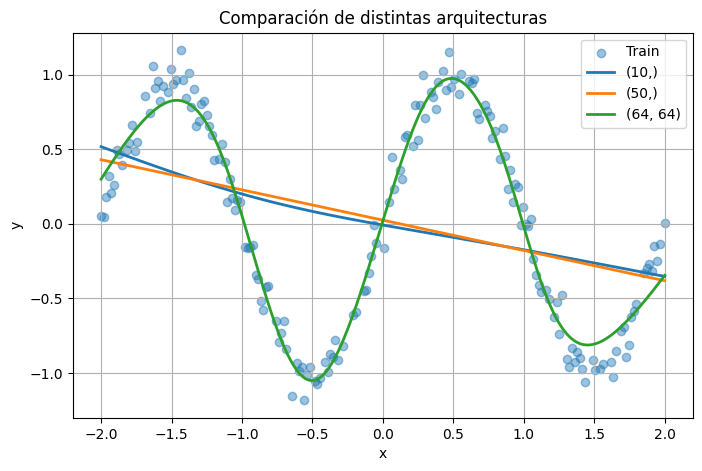

(10,) -> MSE test: 0.4568
(50,) -> MSE test: 0.4698
(64, 64) -> MSE test: 0.0213


In [17]:
arquitecturas = [(10,), (50,), (64, 64)]
resultados = []

plt.figure(figsize=(8,5))
plt.scatter(X_train, y_train, alpha=0.45, label='Train')

for arch in arquitecturas:
    model = MLPRegressor(
        hidden_layer_sizes=arch,
        activation='tanh',
        solver='adam',
        max_iter=1000,
        random_state=42
    )
    model.fit(X_train_scaled, y_train)
    y_pred_arch = model.predict(X_test_scaled)
    mse_arch = mean_squared_error(y_test, y_pred_arch)
    resultados.append((arch, mse_arch))
    y_plot_arch = model.predict(X_plot_scaled)
    plt.plot(X_plot, y_plot_arch, linewidth=2, label=f'{arch}')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Comparación de distintas arquitecturas')
plt.legend()
plt.grid(True)
plt.show()

for arch, mse_arch in resultados:
    print(f'{arch} -> MSE test: {mse_arch:.4f}')

## 7. MLP con TensorFlow / Keras (versión explícita de la red)

Seguimos utilizando un perceptrón multicapa (MLP), pero ahora definimos manualmente la red:

- número de capas
- número de neuronas
- funciones de activación

Esto nos permite ver con más claridad cómo está construido el modelo y nos acerca al deep learning.

In [18]:

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import StandardScaler

# Escalado (recomendado en redes neuronales)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Definición del modelo
model = Sequential([
    Dense(64, activation='tanh', input_shape=(1,)),  # capa oculta 1 -> forma nueva  Input(shape=(1,)) explicitamente y despues metemos Dense(64, activation='tanh')
    Dense(64, activation='tanh'),                    # capa oculta 2
    Dense(1)                                         # salida (regresión)
])

# Configuración del entrenamiento
model.compile(
    optimizer='adam',   # algoritmo de optimización (gradient descent avanzado)
    loss='mse'          # función de pérdida (igual que antes)
)

# Entrenamiento
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=300,
    verbose=0
)

# Predicción
y_pred_keras = model.predict(X_test_scaled).ravel()

# Evaluación
from sklearn.metrics import mean_squared_error
mse_keras = mean_squared_error(y_test, y_pred_keras)

print(f"MSE (Keras): {mse_keras:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
MSE (Keras): 0.0755


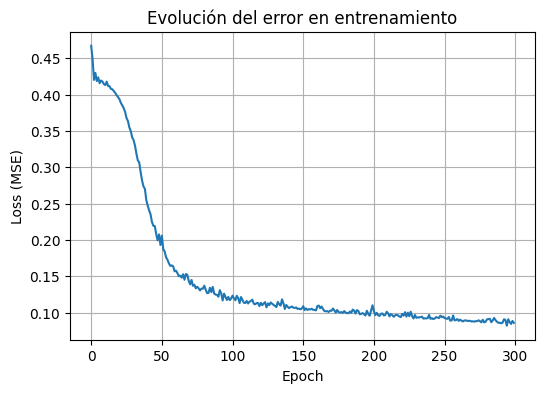

In [19]:
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'])
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("Evolución del error en entrenamiento")
plt.grid(True)
plt.show()

## 8. Idea importante

Un MLP aprende repitiendo este ciclo:

1. Forward pass
2. Cálculo de pérdida
3. Backpropagation
4. Actualización de pesos

Todo ello se repite hasta que el modelo converge o se alcanza el número máximo de iteraciones.

## 9. Conclusiones

- Un MLP puede aprender relaciones no lineales complejas
- Es más flexible que la regresión lineal
- Necesita más hiperparámetros
- Suele requerir escalado y más coste computacional

## 10. Ejercicios

1. Cambiar `hidden_layer_sizes`
2. Probar `activation='relu'`
3. Comparar `max_iter=200` frente a `max_iter=1000`
4. Observar cómo cambia la curva de pérdida